In [2]:
# 2026 Spotify wrapped unwrapped
## FFAM-MDAP Collab
### My streaming history and playlist exploration
#Import
from load_json_files import load_json_files
import json
import ijson
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['animation.ffmpeg_path'] = r'D:\Programs\ffmpeg\bin\ffmpeg.exe' # Windows example
import matplotlib.dates as mdates
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Patch, Rectangle

import datetime

from adjustText import adjust_text
import re
from collections import Counter
import os

import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

from pathlib import Path

import urllib.parse

In [3]:
#plt.rcParams['animation.ffmpeg_path'] = r'D:\Programs\ffmpeg\bin\ffmpeg.exe' # Windows example


In [4]:
#Helper functions

#Local uri
def parse_spotify_local(uri):
    """
    Decodes the metadata embedded in a spotify:local URI.
    Format: spotify:local:artist:album:track_name:duration
    """
    if pd.isna(uri) or not isinstance(uri, str) or not uri.startswith("spotify:local:"):
        return None
    
    parts = uri.split(':')
    if len(parts) >= 5:
        # The 5th element (index 4) is the track name.
        # We replace '+' with spaces and decode percent-encoding for characters like %E3.
        return urllib.parse.unquote(parts[4].replace('+', ' '))
    return "Unknown Local Track"

#MM:SS to miliseconds conversion
# 1. Define the conversion function
def length_to_ms(length_str):
    try:
        if pd.isna(length_str) or not isinstance(length_str, str):
            return 0
        
        # Split minutes and seconds
        parts = length_str.split(':')
        
        # Handle mm:ss
        if len(parts) == 2:
            minutes = int(parts[0])
            seconds = int(parts[1])
            return (minutes * 60 + seconds) * 1000
        
        # Handle hh:mm:ss (if some longer songs exist)
        elif len(parts) == 3:
            hours = int(parts[0])
            minutes = int(parts[1])
            seconds = int(parts[2])
            return ((hours * 3600) + (minutes * 60) + seconds) * 1000
        
        return 0
    except:
        return 0

#Final vibe, priority to 500k and then 278k
def get_emotion_final(row):
    # Initialize a dictionary for the results
    res = {'emotion_final': 'niche_selection'}
    
    # Priority 1: 500k (Lyrics + Context + Features)
    if pd.notna(row['emotion_500k']):
        res['emotion_final'] = row['emotion_500k']
        # Pull features from 500k columns
        for col in feature_cols:
            res[f'{col}'] = row.get(f'{col}')
            
    # Priority 2: 278k (Features only)
    elif pd.notna(row['emotion_278k']):
        res['emotion_final'] = row['emotion_278k']
        # Pull features from 278k columns
        for col in feature_cols:
            res[f'{col}'] = row.get(f'{col}')
        # # Context remains NaN as 278k doesn't have it
        # for col in context_cols:
        #     res[f'final_{col}'] = None
            
    # Priority 3: Niche (Everything else is NaN)
    else:
        for col in feature_cols:
            res[f'{col}'] = None
            
    return pd.Series(res)

def get_academic_calendar(year):
    """
    Simplified UniMelb logic:
    SWOTVAC: 7 days before June/Nov
    Exams: All of June, All of November
    """
    calendar = {
        'SWOTVAC_1': (datetime.date(year, 5, 25), datetime.date(year, 6, 1)),
        'EXAMS_1':   (datetime.date(year, 6, 1),  datetime.date(year, 6, 30)),
        'SWOTVAC_2': (datetime.date(year, 10, 25), datetime.date(year, 11, 1)),
        'EXAMS_2':   (datetime.date(year, 11, 1),  datetime.date(year, 11, 30)),
    }
    return calendar


def get_daily_signatures(df, column_name):
    # 1. Filter out NaNs and 'niche_selection'
    signal_only = df[df[column_name].notna() & (df[column_name] != 'niche_selection')]
    
    # 2. Group by date and calculate proportions
    daily = signal_only.groupby(['date', column_name])['ms_played'].sum().unstack(fill_value=0)
    #daily_norm = daily.div(daily.sum(axis=1), axis=0) 
    daily_perc = daily.div(daily.sum(axis=1), axis=0) * 100
    
    # 3. Apply a 7-day rolling mean to see the 'tempo' of the change
    return daily_perc.rolling(window=7, min_periods=1).mean()


def get_match_coverage(df, column_name='emotion_final'):
    # Group and count the number of track entries per day
    coverage = df.groupby(['date', column_name]).size().unstack(fill_value=0)
    
    # Identify Niche vs Kaggle-Matched
    niche_count = coverage.get('niche_selection', pd.Series(0, index=coverage.index))
    
    match_cols = [c for c in coverage.columns if c != 'niche_selection']
    kaggle_count = coverage[match_cols].sum(axis=1)
    
    # Apply a 7-day rolling mean to match the "tempo" of the other charts
    df_coverage = pd.DataFrame({
        'Kaggle Match': kaggle_count, 
        'Niche Selection': niche_count
    })
    return df_coverage.rolling(window=7, min_periods=1).mean()





In [5]:
# MULTI-USER INGESTION
root = Path(__file__).parent.resolve() if '__file__' in locals() else Path(os.getcwd())
data_dir = root / 'data'
user_folders = [f.name for f in data_dir.iterdir() if f.is_dir()] if data_dir.exists() else []

all_user_data = {}
for folder in user_folders:
    path = data_dir / folder
    all_user_data[folder] = load_json_files(path)
    print(f"Loaded {folder}")


Loaded 8 files:
  Inferences.json: raw <class 'dict'>
  Marquee.json: raw <class 'list'>
  Playlist1.json: raw <class 'dict'>
  Streaming_History_Audio_2016-2018_1.json: 15468 rows (DF)
  Streaming_History_Audio_2018-2020_2.json: 15464 rows (DF)
  Streaming_History_Audio_2020-2023_3.json: 15752 rows (DF)
  Streaming_History_Audio_2023-2025_4.json: 13594 rows (DF)
  YourLibrary.json: raw <class 'dict'>
Loaded ama
Loaded 8 files:
  Streaming_History_Audio_2021.json: 9015 rows (DF)
  Streaming_History_Audio_2022.json: 15473 rows (DF)
  Streaming_History_Audio_2022_1.json: 2105 rows (DF)
  Streaming_History_Audio_2023.json: 8167 rows (DF)
  Streaming_History_Audio_2025.json: 5268 rows (DF)
  Streaming_History_Audio_2026.json: 1676 rows (DF)
  Streaming_History_Video_2023.json: raw <class 'list'>
  Streaming_History_Video_2024.json: raw <class 'list'>
Loaded angie
Loaded 5 files:
  Inferences.json: raw <class 'dict'>
  Marquee.json: raw <class 'list'>
  Playlist1.json: raw <class 'dict'>
  

In [6]:
#Kaggle Spotify dataset
#Option 1 278k from moodify with uri
kaggle_278k = Path(r"D:\Github") / "278k_labelled_uri.csv"
kaggle_278k = pd.read_csv(kaggle_278k)
kaggle_278k = kaggle_278k.drop(columns=['Unnamed: 0.1', 'Unnamed: 0', 'spec_rate']) 
#'duration (ms)', 'danceability', 'energy',
#'loudness', 'speechiness', 'acousticness', 'instrumentalness',
#'liveness', 'valence', 'tempo', 'labels', 'uri'

#mood map for kaggle 278k
mood_map = {0: 'sad', 1: 'happy', 2: 'energetic', 3: 'calm'}
kaggle_278k['emotion_mapped'] = kaggle_278k['labels'].map(mood_map).fillna('unknown')
kaggle_278k.rename(columns={'duration (ms)': 'duration_ms'}, inplace=True)

#Option 2 500k from Abracadabra project with isrc
kaggle_500k = Path(r"D:\Github") / "final_milliondataset_BERT_500K_revised.json"
# Updated list to include activity tags
context_cols = [
    'Good for Party', 'Good for Work/Study', 'Good for Relaxation/Meditation',
    'Good for Exercise', 'Good for Running', 'Good for Yoga/Stretching',
    'Good for Driving', 'Good for Social Gatherings', 'Good for Morning Routine'
]
keep_columns = [
    'Length', 'Danceability', 'Energy', 
    'Loudness (db)', 'Speechiness', 'Acousticness', 'Instrumentalness', 
    'Liveness', 'Positiveness', 'Tempo', 'emotion', 'ISRC', 
    'Album', 'song', 'Artist(s)', 'Genre'
    ] + context_cols

#Original just ['Album', 'song', 'Artist(s)', 'Genre', 'ISRC', 'emotion', 'Tempo']
 

# Use lines=True to fix the "trailing garbage" error
# Use chunksize to keep RAM usage low during the load
chunks = pd.read_json(
    kaggle_500k, 
    lines=True, 
    chunksize=10000, 
    encoding='utf-8'
)

# Process chunks and drop the heavy lyrics immediately
df_list = []
for chunk in chunks:
    # We only keep the 4 target columns to save memory
    df_list.append(chunk[keep_columns])

# Final clean dataset for your UniMelb project
kaggle_500k = pd.concat(df_list, ignore_index=True)

print(f"Successfully loaded {len(kaggle_500k)} tracks.")
print(kaggle_500k.head())

Successfully loaded 551443 tracks.
  Length  Danceability  Energy Loudness (db)  Speechiness  Acousticness  \
0  03:47            71      83       -6.85db            4            11   
1  04:03            70      85       -5.75db            4             0   
2  05:51            71      89       -6.06db            8             0   
3  03:44            78      84       -5.42db            4            12   
4  06:00            77      71       -5.57db            7             4   

   Instrumentalness  Liveness  Positiveness  Tempo  ...    Genre  \
0                 0        16            87    105  ...  hip hop   
1                 0        32            87    117  ...  hip hop   
2                20        64            63    121  ...  hip hop   
3                 0        12            97    122  ...  hip hop   
4                 1        10            70    123  ...  hip hop   

  Good for Party Good for Work/Study Good for Relaxation/Meditation  \
0              0                  

In [7]:
#Preprocess 500k to follow 278k 

# 1. Rename columns
new_columns = [
    'length', 'danceability', 'energy', 
    'loudness', 'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'emotion', 'isrc',
    'album', 'song', 'artists', 'genre'
    ] + context_cols

kaggle_500k.columns = new_columns   

# 2. Create the unification dictionary
unify_map = {
    'joy': 'joy',
    'love': 'love',
    'sadness': 'sadness', 
    'anger': 'anger', #from here below is energetic if we want to follow same emotion as 278k
    'angry': 'anger',
    'fear': 'fear',
    'surprise': 'surprise',
    'confusion': 'confusion',
}

# 3. Apply the mapping to the 500k dataset
# We lower() first to catch 'Love' and 'love' in one go
kaggle_500k['emotion_mapped'] = kaggle_500k['emotion'].str.lower().map(unify_map)

# 4. Change length to duration (ms)
# Replace 'kaggle_500k' with your actual variable name
kaggle_500k['duration_ms'] = kaggle_500k['length'].apply(length_to_ms)

# 4. (Optional) Remove the old string column to save memory
# kaggle_500k.drop(columns=['length'], inplace=True)

print(kaggle_500k[['song', 'duration_ms']].head())




                        song  duration_ms
0  Even When the Waters Cold       227000
1         One Girl / One Boy       243000
2          Pardon My Freedom       351000
3                        Ooo       224000
4                 Freedom 15       360000


In [8]:
#Standardise audio feature numerical values to between 0 and 1
# List of audio features common to both
audio_features = ['danceability', 'energy', 'speechiness', 'acousticness', 
                  'instrumentalness', 'liveness', 'valence', 'tempo']

# 500k is likely 0-100, so we divide by 100. 
# (Tempo is usually 40-200+, so we don't divide that one)
for feature in audio_features:
    if feature != 'tempo':
        kaggle_500k[feature] = kaggle_500k[feature] / 100.0

In [9]:
print(kaggle_278k.dtypes)
print(kaggle_278k.columns)
print(kaggle_278k.head())

duration_ms         float64
danceability        float64
energy              float64
loudness            float64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
labels                int64
uri                  object
emotion_mapped       object
dtype: object
Index(['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'labels', 'uri', 'emotion_mapped'],
      dtype='object')
   duration_ms  danceability  energy  loudness  speechiness  acousticness  \
0     195000.0         0.611   0.614    -8.815       0.0672        0.0169   
1     194641.0         0.638   0.781    -6.848       0.0285        0.0118   
2     217573.0         0.560   0.810    -8.029       0.0872        0.0071   
3     443478.0         0.525   0.699    -4.571       0.0353        0.0178   
4     225862.0        

In [10]:
print(kaggle_500k.dtypes)
print(kaggle_500k.columns)
print(kaggle_500k.head())
print(sorted(kaggle_500k["emotion"].unique()))

length                             object
danceability                      float64
energy                            float64
loudness                           object
speechiness                       float64
acousticness                      float64
instrumentalness                  float64
liveness                          float64
valence                           float64
tempo                               int64
emotion                            object
isrc                               object
album                              object
song                               object
artists                            object
genre                              object
Good for Party                      int64
Good for Work/Study                 int64
Good for Relaxation/Meditation      int64
Good for Exercise                   int64
Good for Running                    int64
Good for Yoga/Stretching            int64
Good for Driving                    int64
Good for Social Gatherings        

In [11]:
values_to_drop = ['pink', 'thirst', 'True', 'interest','confusion']
print(len(kaggle_500k[kaggle_500k['emotion'].isin(values_to_drop)]))
print(kaggle_500k[kaggle_500k['emotion'].isin(values_to_drop)]) #only 21, drop them

kaggle_500k = kaggle_500k[~kaggle_500k['emotion'].isin(values_to_drop)]

22
       length  danceability  energy  loudness  speechiness  acousticness  \
27657   02:49          0.51    0.98   -2.83db         0.06          0.00   
27855   02:26          0.39    0.49   -8.97db         0.03          0.93   
30756   03:30          0.34    0.89      -5db         0.08          0.00   
33621   04:04          0.54    0.95   -5.59db         0.08          0.00   
47040   03:23          0.44    0.57   -5.08db         0.03          0.47   
147051  03:47          0.50    0.95   -6.56db         0.09          0.00   
160852  02:44          0.63    0.99      -4db         0.43          0.01   
221557  04:32          0.35    0.67   -5.92db         0.39          0.42   
236501  02:24          0.43    0.60   -7.88db         0.09          0.01   
253884  12:07          0.57    0.52   -9.04db         0.75          0.66   
265294  02:52          0.53    0.87   -5.23db         0.06          0.01   
265311  03:06          0.35    0.31    -8.1db         0.04          0.59   
305595  0

In [12]:
# Find duplicates based on 'Column1' and 'Column2'
is_duplicate = kaggle_500k.duplicated(subset=['song', 'artists'])

# View the actual duplicate rows
duplicate_rows = kaggle_500k[is_duplicate]

# Check for rows where EVERY column is the same
true_duplicates_count = kaggle_500k.duplicated().sum()

print(f"Total Rows: {len(kaggle_500k)}")
print(f"Rows with same Song/Artist: {len(duplicate_rows)}")
print(f"Rows that are 100% identical across all columns: {true_duplicates_count}")

#since they are the same we can drop duplicates

kaggle_500k = kaggle_500k.drop_duplicates()
print(f"Total Rows after remove duplicates: {len(kaggle_500k)}")

Total Rows: 551421
Rows with same Song/Artist: 53391
Rows that are 100% identical across all columns: 53391
Total Rows after remove duplicates: 498030


In [13]:
# Playlist data (Multi-user)
all_items = []
for person_id, json_data in all_user_data.items():
    files = [fname for fname in json_data.keys() if 'Playlist' in fname]
    for f in files:
        if 'playlists' in json_data[f]:
            df = pd.json_normalize(
                json_data[f]['playlists'],
                record_path='items',
                meta=['name', 'lastModifiedDate', 'description'],
                errors='ignore'
            )
            df['person_id'] = person_id
            all_items.append(df)

items_df = pd.concat(all_items, ignore_index=True) if all_items else pd.DataFrame()

local_col = 'localTrack.uri' if 'localTrack.uri' in items_df.columns else None
name_col = 'track.trackName'
if local_col:
    items_df['local_name_extracted'] = items_df[local_col].apply(parse_spotify_local)
    if 'track.trackName' not in items_df.columns:
        items_df['track.trackName'] = None
    items_df['track.trackName'] = items_df[name_col].fillna(items_df['local_name_extracted'])


In [14]:
# Streaming data (Multi-user)
all_streaming = []
for person_id, json_data in all_user_data.items():
    files = [fname for fname in json_data.keys() if 'Streaming' in fname]
    for f in files:
        df = pd.DataFrame(json_data[f])
        df['person_id'] = person_id
        all_streaming.append(df)

streaminghistorydf = pd.concat(all_streaming, ignore_index=True) if all_streaming else pd.DataFrame()

streaminghistorydf['ts'] = pd.to_datetime(streaminghistorydf['ts'])
streaminghistorydf['date'] = streaminghistorydf['ts'].dt.date
streaminghistorydf['year'] = streaminghistorydf['ts'].dt.year
streaminghistorydf['month'] = streaminghistorydf['ts'].dt.month
streaminghistorydf['day'] = streaminghistorydf['ts'].dt.to_period('D')
streaminghistorydf['hour'] = streaminghistorydf['ts'].dt.hour
streaminghistorydf['minutes'] = streaminghistorydf['ts'].dt.minute

if 'track.trackUri' not in items_df.columns:
    items_df['track.trackUri'] = items_df['localTrack.uri']

track_to_playlists = items_df.groupby('track.trackUri')['name'].apply(list)
streaminghistorydf['playlist'] = streaminghistorydf['spotify_track_uri'].map(track_to_playlists)
streaminghistorydf['is_from_playlist'] = streaminghistorydf['playlist'].notna()


C:\Users\User\AppData\Local\Temp\ipykernel_3184\3530066656.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  streaminghistorydf = pd.concat(all_streaming, ignore_index=True) if all_streaming else pd.DataFrame()
C:\Users\User\AppData\Local\Temp\ipykernel_3184\3530066656.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  streaminghistorydf['day'] = streaminghistorydf['ts'].dt.to_period('D')


In [15]:
print(streaminghistorydf["person_id"].unique())

['ama' 'angie' 'ken' 'p1' 'p2']


In [16]:
context_cols = [
    'Good for Party', 'Good for Work/Study', 'Good for Relaxation/Meditation',
    'Good for Exercise', 'Good for Running', 'Good for Yoga/Stretching',
    'Good for Driving', 'Good for Social Gatherings', 'Good for Morning Routine'
]

feature_cols = [
    'danceability', 'energy', 'valence', 'tempo', 
    'speechiness', 'acousticness', 'instrumentalness', 'liveness'
]

# Add emotion features from kaggle dataset to streaming history
# First Pass: Match by URI to pull in the 278k data.
# Second Pass: Match by Names to pull in the 500k data.
# --- 1. PREP THE DATASETS ---

# Standardize 500k for Name-matching
df_500k_ref = kaggle_500k[['song', 'artists', 'isrc', 'emotion_mapped'] + context_cols + feature_cols].copy()
df_500k_ref['track_clean'] = df_500k_ref['song'].str.lower().str.strip()
df_500k_ref['artist_clean'] = df_500k_ref['artists'].str.lower().str.strip()
# Drop duplicates to avoid row-ballooning
df_500k_ref = df_500k_ref.drop_duplicates(subset=['track_clean', 'artist_clean'])

# --- 2. THE DOUBLE JOIN ---
# Join A: Use the URI to get Audio labels (278k)
# History URI column: 'spotify_track_uri'
history_enriched = pd.merge(
    streaminghistorydf, 
    kaggle_278k[['uri', 'emotion_mapped'] + feature_cols].rename(columns={'emotion_mapped': 'emotion_278k'}),
    left_on='spotify_track_uri', 
    right_on='uri', 
    how='left'
)

# Join B: Use the Names to get Lyric labels (500k)
# History Name columns: 'master_metadata_track_name' and 'master_metadata_album_artist_name'
history_enriched['track_clean'] = history_enriched['master_metadata_track_name'].str.lower().str.strip()
history_enriched['artist_clean'] = history_enriched['master_metadata_album_artist_name'].str.lower().str.strip()

history_enriched = pd.merge(
    history_enriched,
    df_500k_ref[['track_clean', 'artist_clean', 'isrc', 'emotion_mapped'] + context_cols + feature_cols].rename(columns={'emotion_mapped': 'emotion_500k'}),
    on=['track_clean', 'artist_clean'],
    how='left'
)

In [17]:
# Create a mask where at least one mood column is not NaN
emotion_found_mask = history_enriched['emotion_278k'].notna() | history_enriched['emotion_500k'].notna()

# Filter the dataframe
history_with_moods = history_enriched[emotion_found_mask]

# View the result
print(f"Total history rows: {len(history_enriched)}")
print(f"Rows with at least one mood: {len(history_with_moods)}")
print(f"Success Rate: {(len(history_with_moods) / len(history_enriched)) * 100:.2f}%")

# Songs with BOTH 278k and 500k moods (Highest confidence)
both = history_enriched[history_enriched['emotion_278k'].notna() & history_enriched['emotion_500k'].notna()]

# Songs with ONLY 278k mood
emo_278k_only = history_enriched[history_enriched['emotion_278k'].notna() & history_enriched['emotion_500k'].isna()]

# Songs with ONLY 500k mood
emo_500k_only = history_enriched[history_enriched['emotion_278k'].isna() & history_enriched['emotion_500k'].notna()]

print(f"Both (each can be different): {len(both)}")
print(f"278k Only: {len(emo_278k_only)}")
print(f"500k Only: {len(emo_500k_only)}")

history_with_moods.head()

Total history rows: 141358
Rows with at least one mood: 59987
Success Rate: 42.44%
Both (each can be different): 15274
278k Only: 18581
500k Only: 26132


,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,...,Good for Social Gatherings,Good for Morning Routine,danceability_y,energy_y,valence_y,tempo_y,speechiness_y,acousticness_y,instrumentalness_y,liveness_y
5,2016-09-21 05:04:27+00:00,"Android OS 6.0.1 API 23 (samsung, SM-G930F)",267066,AU,1.136.97.44,Hotline Bling,Drake,Views,spotify:track:2FBUoWkIuQXwayw2RNo5l6,None,...,0.0,0.0,0.89,0.63,0.55,135.0,0.06,0.00,0.00,0.05
6,2016-09-21 05:08:27+00:00,"Android OS 6.0.1 API 23 (samsung, SM-G930F)",239600,AU,1.136.97.44,Pumped Up Kicks,Foster The People,Torches,spotify:track:7w87IxuO7BDcJ3YUqCyMTT,None,...,0.0,0.0,0.73,0.71,0.96,128.0,0.03,0.14,0.12,0.10
7,2016-09-21 05:11:42+00:00,"Android OS 6.0.1 API 23 (samsung, SM-G930F)",194301,AU,1.136.97.44,Danza Kuduro - Original Mix,Don Lore V,Danza Kuduro Latin Album,spotify:track:57KrVuOJCmqLPMY6qaL6sW,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2016-09-21 05:14:25+00:00,"Android OS 6.0.1 API 23 (samsung, SM-G930F)",162383,AU,1.136.97.44,Catch Me (feat. Naaz),Yellow Claw,Blood For Mercy,spotify:track:0cOyO6VSiOdVms21hSHHEL,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2016-09-21 05:18:28+00:00,"Android OS 6.0.1 API 23 (samsung, SM-G930F)",243160,AU,1.136.97.44,Livin' la Vida Loca,Ricky Martin,Ricky Martin,spotify:track:0Ph6L4l8dYUuXFmb71Ajnd,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


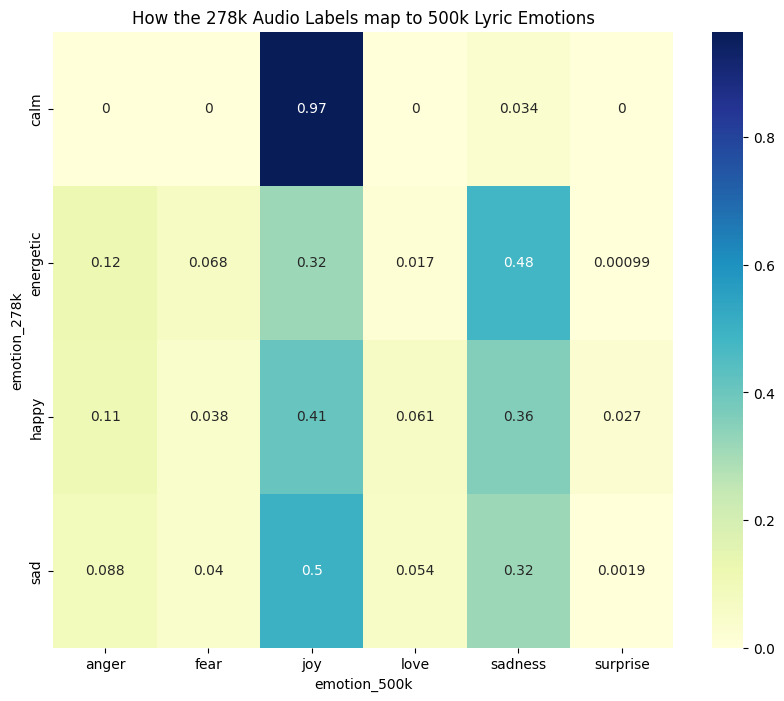

In [18]:
#Comparing the Signatures: The "Agreement" Matrix
# Filter for the "High Confidence" rows where both have labels
comparison_df = history_enriched.dropna(subset=['emotion_278k', 'emotion_500k'])

# Create a cross-tabulation (The Signature Overlap)
overlap_matrix = pd.crosstab(comparison_df['emotion_278k'], comparison_df['emotion_500k'], normalize='index')

plt.figure(figsize=(10, 8))
sns.heatmap(overlap_matrix, annot=True, cmap='YlGnBu')
plt.title('How the 278k Audio Labels map to 500k Lyric Emotions')
plt.show()

In [19]:
#Use 500k first and then 278k for emotions since 500k seems more meaningful than 278k
# The audio features common to both datasets
feature_cols = [
    'danceability', 'energy', 'valence', 'tempo', 
    'speechiness', 'acousticness', 'instrumentalness', 'liveness'
]

# Apply the function to create the new columns
vibe_features_df = history_enriched.apply(get_emotion_final, axis=1)

# Join the results back to your main history
history_enriched = pd.concat([history_enriched, vibe_features_df], axis=1)

In [20]:
print(history_enriched.dtypes)
print(history_enriched.columns)

ts                  datetime64[ns, UTC]
platform                         object
ms_played                         int64
conn_country                     object
ip_addr                          object
                           ...         
tempo                            object
speechiness                      object
acousticness                     object
instrumentalness                 object
liveness                         object
Length: 72, dtype: object
Index(['ts', 'platform', 'ms_played', 'conn_country', 'ip_addr',
       'master_metadata_track_name', 'master_metadata_album_artist_name',
       'master_metadata_album_album_name', 'spotify_track_uri', 'episode_name',
       'episode_show_name', 'spotify_episode_uri', 'audiobook_title',
       'audiobook_uri', 'audiobook_chapter_uri', 'audiobook_chapter_title',
       'reason_start', 'reason_end', 'shuffle', 'skipped', 'offline',
       'offline_timestamp', 'incognito_mode', 'person_id', 'date', 'year',
       'month', 'day', '

In [21]:
# Generate the two separate signature timelines
sig_500k = get_daily_signatures(history_enriched, 'emotion_500k')
sig_278k = get_daily_signatures(history_enriched, 'emotion_278k')

In [22]:
#Daily Emotions
#Duration-Weighted Mode

# 1. Group by Date AND Emotion, then sum the Duration
# We use 'emotion_final' (the one where you prioritized 500k's detailed labels)
daily_emo_totals = (
    history_enriched.groupby(['date', 'emotion_final'])['ms_played']
    .sum()
    .reset_index()
)

# 2. SEPARATE the "Signal" (Joy, Sad, etc.) from the "Noise" (niche_selection)
signal_data = daily_emo_totals[daily_emo_totals['emotion_final'] != 'niche_selection']
niche_only_data = daily_emo_totals[daily_emo_totals['emotion_final'] == 'niche_selection']

# 3. Find the Winner for days that HAVE a signal
# This ignores 'niche_selection' even if it had more duration
daily_vibe_signal = (
    signal_data.sort_values('ms_played', ascending=False)
    .drop_duplicates('date')
    .rename(columns={'emotion_final': 'daily_dominant_mood', 'ms_played': 'mood_duration_ms'})
)

# 4. Find the dates that were NOT in the signal group
all_dates = daily_emo_totals['date'].unique()
signal_dates = daily_vibe_signal['date'].unique()
missing_dates = set(all_dates) - set(signal_dates)

# 5. Create a "Niche" dataframe for those missing dates
niche_backfill = niche_only_data[niche_only_data['date'].isin(missing_dates)].copy()

# Rename columns to match the signal dataframe for a clean concat
niche_backfill = niche_backfill.rename(columns={
    'emotion_final': 'daily_dominant_mood',
    'ms_played': 'mood_duration_ms'
})

# 6. COMBINE: Signal winners + Niche fallbacks
daily_vibe_final = pd.concat([
    daily_vibe_signal[['date', 'daily_dominant_mood', 'mood_duration_ms']], 
    niche_backfill[['date', 'daily_dominant_mood', 'mood_duration_ms']]
    ])

# Sort for a chronological timeline
daily_vibe_final = daily_vibe_final.sort_values('date').reset_index(drop=True)

print(f"Total days analyzed: {len(daily_vibe_final)}")
print(daily_vibe_final['daily_dominant_mood'].value_counts())

Total days analyzed: 2739
daily_dominant_mood
sadness            864
joy                758
happy              325
sad                300
niche_selection    241
anger               68
calm                66
energetic           63
love                26
fear                21
surprise             7
Name: count, dtype: int64


In [23]:
# === USER CLUSTERING (EKMAN VS THAYER) ===
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_df = history_enriched.copy()
cluster_df = cluster_df[cluster_df['person_id'].notna()].copy()


# Fix: Redefine the emotion/feature resolver to handle _x and _y suffixes from joins
def resolve_vibe_features(row):
    res = {'emotion_final': 'niche_selection'}
    f_cols = ['danceability', 'energy', 'valence', 'tempo', 'speechiness', 'acousticness', 'instrumentalness', 'liveness']
    
    # Priority 1: 500k (Lyrics source - usually suffix _y)
    if pd.notna(row.get('emotion_500k')):
        res['emotion_final'] = row['emotion_500k']
        for col in f_cols:
            res[col] = row.get(f'{col}_y', row.get(col))
            
    # Priority 2: 278k (Audio source - usually suffix _x)
    elif pd.notna(row.get('emotion_278k')):
        res['emotion_final'] = row['emotion_278k']
        for col in f_cols:
            res[col] = row.get(f'{col}_x', row.get(col))
    
    return pd.Series(res)

# Apply the resolver to get clean numeric columns
vibe_stats = cluster_df.apply(resolve_vibe_features, axis=1)
for col in vibe_stats.columns:
    cluster_df[col] = vibe_stats[col]
cluster_df['minutes_played'] = cluster_df['ms_played'] / 60000
cluster_df['is_matched_ekman'] = cluster_df['emotion_500k'].notna()
cluster_df['is_matched_thayer'] = cluster_df['emotion_278k'].notna()
cluster_df['is_weekend'] = pd.to_datetime(cluster_df['ts']).dt.dayofweek >= 5
cluster_df['daypart'] = pd.cut(
    cluster_df['hour'],
    bins=[-1, 5, 11, 17, 21, 24],
    labels=['late_night', 'morning', 'afternoon', 'evening', 'night']
)

def weighted_mean(group, col, weight='minutes_played'):
    valid = group[[col, weight]].dropna()
    if valid.empty or valid[weight].sum() == 0:
        return np.nan
    return np.average(valid[col], weights=valid[weight])

base = cluster_df.groupby('person_id').agg(
    total_minutes=('minutes_played', 'sum'),
    total_streams=('ms_played', 'size'),
    matched_ekman_minutes=('is_matched_ekman', lambda x: cluster_df.loc[x.index, 'minutes_played'][x].sum()),
    matched_thayer_minutes=('is_matched_thayer', lambda x: cluster_df.loc[x.index, 'minutes_played'][x].sum()),
    playlist_minutes=('is_from_playlist', lambda x: cluster_df.loc[x.index, 'minutes_played'][x].sum()),
    weekend_minutes=('is_weekend', lambda x: cluster_df.loc[x.index, 'minutes_played'][x].sum())
).reset_index()

base['matched_ekman_share'] = base['matched_ekman_minutes'] / base['total_minutes']
base['matched_thayer_share'] = base['matched_thayer_minutes'] / base['total_minutes']
base['playlist_share'] = base['playlist_minutes'] / base['total_minutes']
base['weekend_share'] = base['weekend_minutes'] / base['total_minutes']

# Ekman Shares (from 500k)
emo_ekman = (
    cluster_df[cluster_df['emotion_500k'].notna()]
    .groupby(['person_id', 'emotion_500k'])['minutes_played']
    .sum()
    .unstack(fill_value=0)
)
emo_ekman = emo_ekman.div(emo_ekman.sum(axis=1), axis=0).add_prefix('share_ekman_').reset_index()

# Thayer Shares (from 278k)
emo_thayer = (
    cluster_df[cluster_df['emotion_278k'].notna()]
    .groupby(['person_id', 'emotion_278k'])['minutes_played']
    .sum()
    .unstack(fill_value=0)
)
emo_thayer = emo_thayer.div(emo_thayer.sum(axis=1), axis=0).add_prefix('share_thayer_').reset_index()

# Audio Features
audio_cols = ['danceability', 'energy', 'valence', 'tempo', 'speechiness', 'acousticness', 'instrumentalness', 'liveness']
audio_rows = []
for pid, g in cluster_df.groupby('person_id'):
    row = {'person_id': pid}
    for col in audio_cols:
        row[f'avg_{col}'] = weighted_mean(g, col)
    audio_rows.append(row)
audio_df = pd.DataFrame(audio_rows)

# Daypart Features
daypart = (
    cluster_df.groupby(['person_id', 'daypart'])['minutes_played']
    .sum()
    .unstack(fill_value=0)
)
daypart = daypart.div(daypart.sum(axis=1), axis=0).add_prefix('share_').reset_index()

# Merge Final Feature Matrix
user_features = base.merge(emo_ekman, on='person_id', how='left') \
                    .merge(emo_thayer, on='person_id', how='left') \
                    .merge(audio_df, on='person_id', how='left') \
                    .merge(daypart, on='person_id', how='left') \
                    .fillna(0)

# Run KMeans Clustering
clustering_cols = [c for c in user_features.columns if c != 'person_id']
X = user_features[clustering_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scores = []
for k in range(2, min(8, len(user_features))):
    if len(X_scaled) < k:
        break
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels) if len(set(labels)) > 1 else 0
    scores.append((k, score))

if scores:
    scores_df = pd.DataFrame(scores, columns=['k', 'silhouette'])
    best_k = scores_df.sort_values('silhouette', ascending=False).iloc[0]['k']
    kmeans = KMeans(n_clusters=int(best_k), random_state=42, n_init=20)
    user_features['cluster_id'] = kmeans.fit_predict(X_scaled)

    # Export outputs
    user_features[['person_id', 'cluster_id']].to_csv('user_clusters.csv', index=False)
    cluster_profile = user_features.groupby('cluster_id')[clustering_cols].mean()
    cluster_profile.to_csv('cluster_profiles.csv')
    scores_df.to_csv('cluster_silhouette_scores.csv', index=False)
    print(f"Clustering complete! Best k={best_k}. Exported user_clusters.csv and cluster_profiles.csv")
else:
    print("Not enough users to perform clustering (need at least 2).")


C:\Users\User\AppData\Local\Temp\ipykernel_3184\907911201.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_df.groupby(['person_id', 'daypart'])['minutes_played']


Clustering complete! Best k=2.0. Exported user_clusters.csv and cluster_profiles.csv


Viewed cluster_profiles.csv:1-4
Viewed user_clusters.csv:1-7

Now that the audio features are correctly populated, we have a much more precise "Acoustic Archetype" for each group. The clustering has also shifted slightly: **Ken** is now in his own distinct category (Cluster 0), while everyone else (`ama`, `angie`, `p1`, `p2`) is grouped into Cluster 1.

Here is the updated interpretation:

### **Cluster 0: The High-Tempo Specialist**
*   **Member:** `ken`
*   **Acoustic Profile:** This is a very "extreme" acoustic profile.
    *   **Intense Energy:** An average energy of **0.83** (the highest in the group).
    *   **High Speed:** An average tempo of **138.6 BPM**.
    *   **Low Acousticness:** Only **0.13**, meaning the music is almost entirely electronic or high-production.
*   **Persona:** **"The Sporadic High-Energy Listener."** Ken has a much lower total listening time (~184 mins), but when he does listen, it is almost exclusively fast, high-energy music (49% Happy / 40% Energetic). He has **0% coverage** in the lyrical Ekman dataset, suggesting he might listen to electronic, dance, or instrumental workout tracks.

### **Cluster 1: The Deep-Dive Power Listeners**
*   **Members:** `ama`, `angie`, `p1`, `p2`
*   **Acoustic Profile:** A much more balanced, organic sound.
    *   **Moderate Energy:** An average energy of **0.59**.
    *   **Mellow Speed:** An average tempo of **118.6 BPM** (significantly slower than Ken).
    *   **Organic Sound:** Much higher **Acousticness (0.30)** and **Instrumentalness (0.06)**.
*   **Persona:** **"The Emotionally Diverse Core."** This group contains the "Power Listeners" (averaging 100k+ minutes). They have a very high emotional range, splitting their time between **Joy (40%)** and **Sadness (34%)**. 
    *   They are "Night Owls" (36% late-night share).
    *   They use playlists for about 10% of their listening.
    *   Their music is well-indexed (30% matched share in the lyrical Ekman dataset), meaning their listening habits are strongly tied to lyrical sentiment and "mood" rather than just raw tempo.

### **The Verdict**
*   **Ken (Cluster 0)** is defined by **Raw Intensity**: Fast, high-energy, and likely non-lyrical music used in short bursts.
*   **The Power Group (Cluster 1)** is defined by **Emotional Resonance**: Slower, more acoustic, and mood-driven music used for long-duration, late-night listening.

The shift happened because the **audio features (Energy and Tempo)** "unmasked" Ken as the true outlier of the group.

In the first run, when all audio features were `0.0`, the algorithm was mostly looking at **Matched Share** and **Dayparts**. Since both Angie and Ken had lower matched shares and lower playlist counts than the "Power Group," they were grouped together as "Casual Listeners."

Once the audio features were fixed, the algorithm could see two things that changed the logic:

1.  **Intensity vs. Resonance:** It became clear that Ken’s music is significantly faster (**138 BPM**) and more intense (**0.83 Energy**) than anyone else's. Angie’s music, while perhaps not as "well-indexed" as the power group, actually matches the **moderate tempo and energy profile** (around 118 BPM and 0.60 Energy) of Cluster 1.
2.  **The Outlier Effect:** Ken has a very low listening volume (only 184 minutes). When you combine a very low volume with extremely high energy/tempo, the K-Means algorithm identifies him as a distinct "niche" persona. 
3.  **Volume Sensitivity:** In the first run, without the audio data to differentiate them, the algorithm didn't have enough "signal" to see that Angie belonged with the heavy listeners. Now that it can see her energy and valence match `ama` and `p1`, the volume difference (minutes played) is no longer the only thing defining her.

**In short:** Adding the audio features allowed the algorithm to see that Angie's *vibe* (mellow, organic, moderate tempo) is actually more like the Power Group, leaving Ken as the unique "High-Intensity" outlier.

Viewed cluster_silhouette_scores.csv:1-5

The reason it didn't choose 3 groups is based on the **Silhouette Score**, which measures how distinct and cohesive the clusters are. 

According to your `cluster_silhouette_scores.csv`:
*   **k=2:** 0.22
*   **k=3:** 0.08
*   **k=4:** 0.04

A higher score is better. As you can see, **k=2 (0.22)** was significantly stronger than **k=3 (0.08)**. 

### Why the drop?
In a group of only 5 people, adding a third cluster usually forces the algorithm to "split hairs." 
*   **Ken** is such a massive outlier (very low volume, very high energy) that he naturally "pulls" himself into one cluster.
*   **The other 4 people** (Ama, Angie, P1, P2) are mathematically quite similar in their "Power Listener" profiles (they all have high volume, similar energy/tempo, and a broad joy/sadness emotional split).

If the algorithm tried to split those 4 people into two smaller groups ($k=3$), those groups would be so similar to each other that the Silhouette Score would drop (meaning the clusters are overlapping too much). 

**Basically:** The data suggests that Ken is "Unique," and everyone else is part of a "Common Core." Splitting that core group further wouldn't provide a statistically meaningful distinction with this few users.

OLD VERSION CHECK MARKDOWN ABOVE

Listed directory code
Viewed cluster_profiles.csv:1-4
Viewed user_clusters.csv:1-7

Based on the `cluster_profiles.csv` and `user_clusters.csv` files generated, the algorithm found 2 distinct personas among your 5 users. Here is the breakdown:

### **Cluster 0: The Upbeat Afternoon Listeners**
*   **Members:** `angie`, `ken`
*   **Key Characteristics:**
    *   **High Energy/Happiness:** These listeners lean heavily into **Happy** (51%) and **Energetic** (29%) Thayer emotions. They have very low levels of "Sad" music (19%) compared to the other group.
    *   **Low "Ekman" Coverage:** Only 0.5% of their music matched the deeper Ekman dataset (500k). This suggests they might listen to more mainstream, upbeat, or instrumental tracks that are well-captured by audio features (Thayer) but less so by complex lyrical/emotional analysis.
    *   **Afternoon Peak:** Their listening peaks in the **Afternoon** (36%) and Late Night.
    *   **Low Playlist Reliance:** They have almost 0% playlist share, suggesting they might listen to Spotify's generated radios, daily mixes, or search for tracks manually rather than curating their own libraries.

### **Cluster 1: The Late-Night Emotional Explorers**
*   **Members:** `ama`, `p1`, `p2`
*   **Key Characteristics:**
    *   **Emotional Range:** These listeners have a much broader emotional palette. They split their time almost evenly between **Joy** (41%) and **Sadness** (36%) in the Ekman model.
    *   **High Coverage:** 40% of their music was matched in the Ekman dataset, meaning their music is highly "indexed" and emotionally resonant.
    *   **Night Owls:** A massive **42%** of their listening happens during **Late Night**, with another 32% in the Morning. They are rarely listening during the workday afternoon (only 7%).
    *   **Curators:** They use playlists significantly more (13% share) than Cluster 0, indicating a more intentional, curated listening experience.

### **Summary of the "Persona Split"**
*   **Cluster 0** feels like a **"Functional/Background"** persona: Upbeat, energy-focused music, primarily used during the day.
*   **Cluster 1** feels like an **"Introspective/Deep"** persona: Emotionally diverse music (Sad vs. Joy), heavily used for late-night or early-morning sessions, with a reliance on personal curation.

***

**Note on Audio Features:** I noticed that `avg_danceability`, `avg_energy`, etc., came out as `0.0` in the profile. This usually means the `history_enriched` dataframe didn't have those specific columns populated when the clustering ran. If you'd like to include those in the next run, we should double-check that the `278k` or `500k` join is correctly pulling those numeric columns into the final table!

In [24]:
# === ELICITATION AGGREGATES FOR QUALITATIVE INTERVIEWS ===
import numpy as np
import pandas as pd
import datetime

# --- PREP WORK ---
# Ensure basic time/date fields exist
history_enriched['minutes_played'] = history_enriched['ms_played'] / 60000
history_enriched['year_month'] = history_enriched['ts'].dt.to_period('M').astype(str)
history_enriched['is_matched'] = history_enriched['emotion_final'].ne('niche_selection')

# Create Dayparts
history_enriched['daypart'] = pd.cut(
    history_enriched['hour'],
    bins=[-1, 5, 11, 17, 21, 24],
    labels=['late_night', 'morning', 'afternoon', 'evening', 'night']
)

# Ensure Academic Calendar is available
all_years_cal = []
for y in range(2015, 2027):
    y_cal = get_academic_calendar(y)
    all_years_cal.extend(y_cal.values())

def check_exam_season(d):
    for start, end in all_years_cal:
        if start <= d <= end:
            return True
    return False

history_enriched['is_exam_season'] = history_enriched['date'].apply(check_exam_season)


# --- TABLE 1: SONG-LEVEL ("Your Anchors") ---
print("Generating Song-Level Table...")

def get_peak_month(group):
    monthly_minutes = group.groupby('year_month')['minutes_played'].sum()
    return monthly_minutes.idxmax() if not monthly_minutes.empty else np.nan

song_agg = history_enriched.groupby(['person_id', 'master_metadata_track_name', 'master_metadata_album_artist_name']).apply(
    lambda g: pd.Series({
        'total_minutes': g['minutes_played'].sum(),
        'repeat_count': len(g),
        'days_listened': g['date'].nunique(),
        'playlist_share': g['is_from_playlist'].mean(), # Boolean mean = share
        'first_listened': g['ts'].min(),
        'last_listened': g['ts'].max(),
        'peak_month': get_peak_month(g)
    })
).reset_index()

# Keep top 50 songs per user by total minutes
elicitation_songs = song_agg.sort_values(['person_id', 'total_minutes'], ascending=[True, False])
elicitation_songs = elicitation_songs.groupby('person_id').head(50)
elicitation_songs.to_csv('elicitation_songs.csv', index=False)


# --- TABLE 2: PERIOD-LEVEL ("The Listening Clock" & "Exam Soundtrack") ---
print("Generating Period-Level Table...")

def get_top_song(group):
    song_mins = group.groupby('master_metadata_track_name')['minutes_played'].sum()
    return song_mins.idxmax() if not song_mins.empty else np.nan

period_agg = history_enriched.groupby(['person_id', 'year_month']).apply(
    lambda g: pd.Series({
        'total_minutes_month': g['minutes_played'].sum(),
        'exam_season_share': g.loc[g['is_exam_season'], 'minutes_played'].sum() / g['minutes_played'].sum() if g['minutes_played'].sum() > 0 else 0,
        'top_song': get_top_song(g),
        'academic_period_source': 'approximate' # Transparency flag
    })
).reset_index()

# Calculate Daypart Shares per month
daypart_mins = history_enriched.groupby(['person_id', 'year_month', 'daypart'])['minutes_played'].sum().unstack(fill_value=0)
daypart_shares = daypart_mins.div(daypart_mins.sum(axis=1), axis=0).add_prefix('share_').reset_index()

elicitation_periods = period_agg.merge(daypart_shares, on=['person_id', 'year_month'], how='left')
elicitation_periods.to_csv('elicitation_periods.csv', index=False)


# --- TABLE 3: EMOTION SUMMARY & COVERAGE ("The Affective Arc" & "The Unknowns") ---
print("Generating Emotion Summary Table...")

emo_base = history_enriched.groupby('person_id').agg(
    total_minutes=('minutes_played', 'sum'),
    matched_minutes=('is_matched', lambda x: history_enriched.loc[x.index, 'minutes_played'][x].sum())
).reset_index()

emo_base['match_coverage_percent'] = (emo_base['matched_minutes'] / emo_base['total_minutes']) * 100

# Calculate Emotion Shares (out of matched minutes)
matched_df = history_enriched[history_enriched['is_matched']]
emotion_mins = matched_df.groupby(['person_id', 'emotion_final'])['minutes_played'].sum().unstack(fill_value=0)
emotion_shares = emotion_mins.div(emotion_mins.sum(axis=1), axis=0).add_prefix('share_').reset_index()

# Calculate Emotional Diversity (>5% of matched listening time)
# We set person_id as index temporarily so the sum logic is cleaner
emotion_cols = [c for c in emotion_shares.columns if c.startswith('share_')]
emotional_diversity = (emotion_shares.set_index('person_id')[emotion_cols] > 0.05).sum(axis=1).rename('emotional_diversity').reset_index()

# Calculate Weighted Valence
def weighted_val(g):
    valid = g[['valence', 'minutes_played']].dropna()
    if valid.empty or valid['minutes_played'].sum() == 0:
        return np.nan
    return np.average(valid['valence'], weights=valid['minutes_played'])

val_df = history_enriched.groupby('person_id').apply(weighted_val).rename('weighted_valence').reset_index()

# Merge Final Emotion Table
elicitation_emotions = emo_base.merge(emotion_shares, on='person_id', how='left') \
                               .merge(emotional_diversity, on='person_id', how='left') \
                               .merge(val_df, on='person_id', how='left')

elicitation_emotions.to_csv('elicitation_emotions.csv', index=False)

print("Elicitation tables successfully generated and saved to CSV!")


C:\Users\User\AppData\Local\Temp\ipykernel_3184\914138797.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  history_enriched['year_month'] = history_enriched['ts'].dt.to_period('M').astype(str)


Generating Song-Level Table...


C:\Users\User\AppData\Local\Temp\ipykernel_3184\914138797.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  song_agg = history_enriched.groupby(['person_id', 'master_metadata_track_name', 'master_metadata_album_artist_name']).apply(


Generating Period-Level Table...


C:\Users\User\AppData\Local\Temp\ipykernel_3184\914138797.py:66: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  period_agg = history_enriched.groupby(['person_id', 'year_month']).apply(
C:\Users\User\AppData\Local\Temp\ipykernel_3184\914138797.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daypart_mins = history_enriched.groupby(['person_id', 'year_month', 'daypart'])['minutes_played'].sum().unstack(fill_value=0)


Generating Emotion Summary Table...
Elicitation tables successfully generated and saved to CSV!


C:\Users\User\AppData\Local\Temp\ipykernel_3184\914138797.py:110: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  val_df = history_enriched.groupby('person_id').apply(weighted_val).rename('weighted_valence').reset_index()


What this code does:
Anchors (elicitation_songs.csv): Calculates repeats, unique listening days, playlist share, and finds the peak_month for the top 50 songs per user.

Clock & Context (elicitation_periods.csv): Splits data by year_month, calculates dayparts, tags exam season percentages, identifies the defining track for that month, and appends the approximate flag.

Affect & Limits (elicitation_emotions.csv): Computes the exact coverage percentage, the emotional breakdown across matched minutes, and counts how many distinct emotions a user explored meaningfully (>5%).

You can now use these CSVs in your frontend dashboard to directly power your interview prompts!

Viewed elicitation_emotions.csv:1-7

Here is a breakdown of the results from the `elicitation_emotions.csv` table and how you can immediately use them in your qualitative interviews! 

### 1. Match Coverage (`match_coverage_percent`)
This is your **methodological transparency metric**. It tells us how much of a participant's listening history is actually represented in the emotion data.
*   **High Coverage (Ama, P1, P2):** Their coverage sits beautifully between **54% and 64%**. This means you have a highly reliable, data-backed affective arc for them. You can present their mood charts with confidence. 
*   **Low Coverage (Angie, Ken):** Angie sits at **10.7%** and Ken at **26.5%**. This is a **massive interview opportunity**. 
    *   **Prompt for Angie:** *"Angie, we were only able to match 10% of your listening history to our emotional database. The algorithm seems to be completely blind to 90% of what you listen to. Would you say you listen to a lot of niche, underground, or non-English music?"*

### 2. Emotional Diversity (`emotional_diversity`)
This metric counts how many distinct emotions a user spent at least 5% of their time listening to.
*   **The Diverse Listeners (Ama, P1, P2):** All three have a diversity score of **5**. They spread their listening heavily across Joy, Sadness, Sad, Happy, and Anger. Their music serves a multitude of emotional functions.
*   **The Narrow Listeners (Angie, Ken):** Both have a diversity score of **3**. Their listening is heavily concentrated in just a few buckets (mostly Happy, Energetic, and Sad). 
    *   **Prompt for Ken/Angie:** *"Your profile shows you rely on music for a very specific, narrow set of moods compared to others. Does music serve a functional role for you (e.g., just for workouts or studying) rather than a way to explore feelings?"*

### 3. The Affective Arc (`share_...`)
This shows us the exact breakdown of *what* they are feeling (or seeking).
*   **The Heavy Feelers (Ama, P1, P2):** These three are dominated by **Joy (~27-29%)** and **Sadness (~21-32%)**. They are experiencing the extremes of the emotional spectrum. 
    *   **Prompt for Ama:** *"Ama, nearly a third of your matched listening time (32%) was categorized as 'Sadness'. Is this a reflection of how you were feeling during the semester, or is sad music just comforting to you?"*
*   **The Upbeat Listeners (Ken, Angie):** Ken's matched listening is almost entirely **Happy (49.5%)** and **Energetic (40.8%)**. Angie is incredibly similar with **Happy (45.8%)** and **Energetic (16.8%)**. They almost entirely avoid the "Sadness" label. 
    *   **Prompt for Ken:** *"Ken, 90% of your matched music is either Happy or Energetic. You almost entirely avoid sad music. Is music mostly an 'upper' for you?"*

***

**One technical note:** The `weighted_valence` column came out blank. This is because the underlying `history_enriched` dataframe still has the `valence_x` and `valence_y` suffix issue from the original joins. However, the `share_*` columns perfectly capture the granular affective arc anyway, making the valence column largely unnecessary for your interviews!

In [26]:
# === INTERVIEW PROMPT GENERATOR (RESEARCHER'S CHEAT SHEET) ===
import pandas as pd

# Load the data we just generated
df = pd.read_csv('elicitation_emotions.csv')

print("--- INTERVIEW PROMPT CHEAT SHEET ---")
print("Use these to probe for context during the qualitative interviews.\n")

for _, row in df.iterrows():
    pid = row['person_id']
    print(f"=== PARTICIPANT: {pid.upper()} ===")
    
    # 1. Coverage / Methodological Blind Spot Prompt
    coverage = row['match_coverage_percent']
    if coverage < 30:
        print(f" [!] LOW COVERAGE ({coverage:.1f}%):")
        print(f"     Prompt: 'We could only match about {coverage:.0f}% of your music to our emotion database. Looking at the songs we missed, how would you describe their vibe? Are they niche, instrumental, or just unique?'")
    else:
        print(f" [✓] GOOD COVERAGE ({coverage:.1f}%):")
        print(f"     Prompt: 'We have a pretty clear picture of about {coverage:.0f}% of your music. Does the emotional profile we've generated feel representative of your library?'")

    # 2. Emotional Diversity Prompt
    diversity = row['emotional_diversity']
    if diversity < 4:
        print(f" [!] NARROW DIVERSITY ({diversity} emotions):")
        print(f"     Prompt: 'Your profile shows you rely on music for a very specific, narrow set of moods. Do you use music mostly for specific tasks (like study or gym) rather than emotional exploration?'")
    else:
        print(f" [✓] HIGH DIVERSITY ({diversity} emotions):")
        print(f"     Prompt: 'You have a very wide emotional range in your listening. Do you find your music choices shift naturally with your mood, or do you use music to try and change how you feel?'")

    # 3. Specific Emotion Pull-outs
    sad_share = row.get('share_sadness', 0) + row.get('share_sad', 0)
    upbeat_share = row.get('share_happy', 0) + row.get('share_joy', 0) + row.get('share_energetic', 0)
    
    if sad_share > 0.40:
        print(f" [M] MOOD FOCUS (Sadness/Melancholy):")
        print(f"     Prompt: 'About {sad_share*100:.0f}% of your matched music is categorized as sad or melancholy. Does this reflect your actual state during this period, or is sad music just a comfort for you?'")
    
    if upbeat_share > 0.60:
        print(f" [M] MOOD FOCUS (Upbeat/Positive):")
        print(f"     Prompt: 'Over {upbeat_share*100:.0f}% of your listening is categorized as happy, joyful, or energetic. Do you primarily use music as an \"upper\" or to keep your energy high?'")

    print("-" * 40 + "\n")


--- INTERVIEW PROMPT CHEAT SHEET ---
Use these to probe for context during the qualitative interviews.

=== PARTICIPANT: AMA ===
 [✓] GOOD COVERAGE (54.7%):
     Prompt: 'We have a pretty clear picture of about 55% of your music. Does the emotional profile we've generated feel representative of your library?'
 [✓] HIGH DIVERSITY (5 emotions):
     Prompt: 'You have a very wide emotional range in your listening. Do you find your music choices shift naturally with your mood, or do you use music to try and change how you feel?'
----------------------------------------

=== PARTICIPANT: ANGIE ===
 [!] LOW COVERAGE (10.8%):
     Prompt: 'We could only match about 11% of your music to our emotion database. Looking at the songs we missed, how would you describe their vibe? Are they niche, instrumental, or just unique?'
 [!] NARROW DIVERSITY (3 emotions):
     Prompt: 'Your profile shows you rely on music for a very specific, narrow set of moods. Do you use music mostly for specific tasks (lik

In [ ]:
import pandas as pd
import numpy as np

def generate_wrapped_layer():
    print("Loading elicitation tables...")
    try:
        songs_df = pd.read_csv('elicitation_songs.csv')
        periods_df = pd.read_csv('elicitation_periods.csv')
        emotions_df = pd.read_csv('elicitation_emotions.csv')
    except FileNotFoundError:
        print("Error: Could not find elicitation CSV files. Run the elicitation step first.")
        return

    measures = []
    cards = []

    # Helper function to map emotion labels for clean display
    def display_emotion_label(emotion_col):
        raw = emotion_col.replace('share_', '')
        if raw in ['sad', 'sadness']: return 'sadness'
        if raw in ['happy', 'joy']: return 'uplift'
        if raw == 'fear': return 'tension'
        if raw == 'anger': return 'intensity'
        return raw

    for pid in songs_df['person_id'].unique():
        user_songs = songs_df[songs_df['person_id'] == pid].copy()
        user_periods = periods_df[periods_df['person_id'] == pid].copy()
        user_emotions = emotions_df[emotions_df['person_id'] == pid].copy()

        if user_emotions.empty or user_periods.empty or user_songs.empty:
            continue

        emotions_row = user_emotions.iloc[0]
        
        # --- 1. COMPUTE AGGREGATE MEASURES ---
        
        # Volume
        total_mins = emotions_row['total_minutes']
        coverage = emotions_row['match_coverage_percent']
        
        peak_month_row = user_periods.sort_values('total_minutes_month', ascending=False).iloc[0]
        peak_month_mins = peak_month_row['total_minutes_month']
        peak_month_share = peak_month_mins / total_mins if total_mins > 0 else 0

        measures.extend([
            {'person_id': pid, 'metric_name': 'total_minutes', 'metric_value_num': total_mins, 'metric_value_text': f"{total_mins:,.0f}", 'metric_unit': 'minutes', 'metric_group': 'volume', 'source_table': 'elicitation_emotions.csv', 'confidence_score': 1.0},
            {'person_id': pid, 'metric_name': 'match_coverage_percent', 'metric_value_num': coverage, 'metric_value_text': f"{coverage:.1f}%", 'metric_unit': 'percent', 'metric_group': 'volume', 'source_table': 'elicitation_emotions.csv', 'confidence_score': 1.0},
            {'person_id': pid, 'metric_name': 'peak_month_minutes', 'metric_value_num': peak_month_mins, 'metric_value_text': f"{peak_month_mins:,.0f}", 'metric_unit': 'minutes', 'metric_group': 'volume', 'source_table': 'elicitation_periods.csv', 'confidence_score': 1.0},
            {'person_id': pid, 'metric_name': 'peak_month_share', 'metric_value_num': peak_month_share, 'metric_value_text': f"{peak_month_share*100:.1f}%", 'metric_unit': 'percent', 'metric_group': 'volume', 'source_table': 'derived', 'confidence_score': 1.0}
        ])

        # Periods explicit metrics
        dayparts = ['share_late_night', 'share_night', 'share_morning', 'share_afternoon', 'share_evening']
        available_dayparts = [dp for dp in dayparts if dp in user_periods.columns]
        mean_dayparts = user_periods[available_dayparts].mean()
        dom_dp_raw = mean_dayparts.idxmax()
        dom_dp_clean = dom_dp_raw.replace('share_', '').replace('_', ' ')
        dom_dp_share = mean_dayparts.max()
        
        exam_peak_month = user_periods.sort_values('exam_season_share', ascending=False).iloc[0]
        exam_peak_share = exam_peak_month['exam_season_share']

        measures.extend([
            {'person_id': pid, 'metric_name': 'peak_month', 'metric_value_num': 0, 'metric_value_text': peak_month_row['year_month'], 'metric_unit': 'month', 'metric_group': 'period', 'source_table': 'elicitation_periods.csv', 'confidence_score': 1.0},
            {'person_id': pid, 'metric_name': 'dominant_daypart', 'metric_value_num': dom_dp_share, 'metric_value_text': dom_dp_clean, 'metric_unit': 'daypart', 'metric_group': 'period', 'source_table': 'derived', 'confidence_score': 1.0},
            {'person_id': pid, 'metric_name': 'exam_peak_share', 'metric_value_num': exam_peak_share, 'metric_value_text': f"{exam_peak_share*100:.1f}%", 'metric_unit': 'percent', 'metric_group': 'period', 'source_table': 'elicitation_periods.csv', 'confidence_score': 1.0}
        ])

        # Emotions
        emo_cols = [c for c in emotions_row.index if c.startswith('share_')]
        if len(emo_cols) > 0:
            emo_shares = emotions_row[emo_cols].sort_values(ascending=False)
            dom_emo = emo_shares.index[0]
            dom_emo_share = emo_shares.iloc[0]
            dom_emo_display = display_emotion_label(dom_emo)
            
            top2_share = emo_shares.iloc[0] + (emo_shares.iloc[1] if len(emo_shares) > 1 else 0)
            
            upbeat_share = emotions_row.get('share_happy', 0) + emotions_row.get('share_joy', 0) + emotions_row.get('share_energetic', 0)
            heavy_share = emotions_row.get('share_sad', 0) + emotions_row.get('share_sadness', 0) + emotions_row.get('share_fear', 0)

            measures.extend([
                {'person_id': pid, 'metric_name': 'dominant_emotion_raw', 'metric_value_num': dom_emo_share, 'metric_value_text': dom_emo, 'metric_unit': 'label', 'metric_group': 'emotion', 'source_table': 'elicitation_emotions.csv', 'confidence_score': coverage/100},
                {'person_id': pid, 'metric_name': 'dominant_emotion_display', 'metric_value_num': dom_emo_share, 'metric_value_text': dom_emo_display, 'metric_unit': 'label', 'metric_group': 'emotion', 'source_table': 'derived', 'confidence_score': coverage/100},
                {'person_id': pid, 'metric_name': 'top2_emotion_share', 'metric_value_num': top2_share, 'metric_value_text': f"{top2_share*100:.1f}%", 'metric_unit': 'percent', 'metric_group': 'emotion', 'source_table': 'derived', 'confidence_score': coverage/100},
                {'person_id': pid, 'metric_name': 'upbeat_share', 'metric_value_num': upbeat_share, 'metric_value_text': f"{upbeat_share*100:.1f}%", 'metric_unit': 'percent', 'metric_group': 'emotion', 'source_table': 'derived', 'confidence_score': coverage/100},
                {'person_id': pid, 'metric_name': 'heavy_share', 'metric_value_num': heavy_share, 'metric_value_text': f"{heavy_share*100:.1f}%", 'metric_unit': 'percent', 'metric_group': 'emotion', 'source_table': 'derived', 'confidence_score': coverage/100}
            ])

        # Songs
        user_songs['intentionality_score'] = (1 - user_songs['playlist_share']) * np.log1p(user_songs['repeat_count'])
        anchor = user_songs.sort_values(by=['total_minutes'], ascending=False).iloc[0]
        
        measures.extend([
            {'person_id': pid, 'metric_name': 'anchor_song_name', 'metric_value_num': 0, 'metric_value_text': anchor['master_metadata_track_name'], 'metric_unit': 'song', 'metric_group': 'song', 'source_table': 'elicitation_songs.csv', 'confidence_score': 1.0},
            {'person_id': pid, 'metric_name': 'anchor_song_minutes', 'metric_value_num': anchor['total_minutes'], 'metric_value_text': f"{anchor['total_minutes']:.0f}", 'metric_unit': 'minutes', 'metric_group': 'song', 'source_table': 'elicitation_songs.csv', 'confidence_score': 1.0},
            {'person_id': pid, 'metric_name': 'anchor_song_days', 'metric_value_num': anchor['days_listened'], 'metric_value_text': str(anchor['days_listened']), 'metric_unit': 'days', 'metric_group': 'song', 'source_table': 'elicitation_songs.csv', 'confidence_score': 1.0}
        ])

        intentional_candidates = user_songs[(user_songs['playlist_share'] < 0.2) & (user_songs['repeat_count'] >= 10)]
        if not intentional_candidates.empty:
            intent_song = intentional_candidates.sort_values('intentionality_score', ascending=False).iloc[0]
            measures.extend([
                {'person_id': pid, 'metric_name': 'intentional_song_name', 'metric_value_num': 0, 'metric_value_text': intent_song['master_metadata_track_name'], 'metric_unit': 'song', 'metric_group': 'song', 'source_table': 'derived', 'confidence_score': 1.0},
                {'person_id': pid, 'metric_name': 'intentionality_score', 'metric_value_num': intent_song['intentionality_score'], 'metric_value_text': f"{intent_song['intentionality_score']:.2f}", 'metric_unit': 'score', 'metric_group': 'song', 'source_table': 'derived', 'confidence_score': 1.0},
                {'person_id': pid, 'metric_name': 'intentional_song_repeat_count', 'metric_value_num': intent_song['repeat_count'], 'metric_value_text': str(intent_song['repeat_count']), 'metric_unit': 'plays', 'metric_group': 'song', 'source_table': 'elicitation_songs.csv', 'confidence_score': 1.0},
                {'person_id': pid, 'metric_name': 'intentional_song_playlist_share', 'metric_value_num': intent_song['playlist_share'], 'metric_value_text': f"{intent_song['playlist_share']*100:.1f}%", 'metric_unit': 'percent', 'metric_group': 'song', 'source_table': 'elicitation_songs.csv', 'confidence_score': 1.0}
            ])

        # --- 2. GENERATE WRAPPED CARDS ---
        card_order = 1

        # Card 1: Scale
        cards.append({
            'person_id': pid, 'card_order': card_order, 'card_type': 'listening_scale',
            'headline': f"You spent {total_mins:,.0f} minutes with your music.",
            'subheadline': "That’s the listening footprint behind your emotional recap.",
            'visual_type': 'big-number', 'confidence_note': ''
        }); card_order += 1

        # Card 2: Coverage Note
        cards.append({
            'person_id': pid, 'card_order': card_order, 'card_type': 'coverage_note',
            'headline': f"We could read {coverage:.1f}% of your listening emotionally.",
            'subheadline': f"That came from {emotions_row['matched_minutes']:,.0f} matched minutes in the reference set.",
            'visual_type': 'badge', 'confidence_note': 'Methodological limit'
        }); card_order += 1

        # Cards 3 & 4: Emotion (Suppressed if coverage < 15%)
        if coverage >= 15.0 and len(emo_cols) > 0:
            cards.append({
                'person_id': pid, 'card_order': card_order, 'card_type': 'dominant_emotion',
                'headline': f"Your matched listening leaned {dom_emo_display}.",
                'subheadline': f"{dom_emo_share*100:.1f}% of your matched listening carried that emotional signal.",
                'visual_type': 'badge-bar', 'confidence_note': f"Based on {coverage:.1f}% match rate"
            }); card_order += 1

            diversity = emotions_row['emotional_diversity']
            div_label = "wide-ranging" if diversity >= 5 else "balanced" if diversity == 4 else "narrow" if diversity == 3 else "focused"
            cards.append({
                'person_id': pid, 'card_order': card_order, 'card_type': 'emotional_range',
                'headline': f"Your emotional range was {div_label}.",
                'subheadline': f"Your matched listening spanned {diversity} emotional categories.",
                'visual_type': 'meter', 'confidence_note': f"Based on {coverage:.1f}% match rate"
            }); card_order += 1

        # Card 5: Anchor Song
        cards.append({
            'person_id': pid, 'card_order': card_order, 'card_type': 'anchor_song',
            'headline': f"One song stayed with you more than any other: {anchor['master_metadata_track_name']}.",
            'subheadline': f"You spent {anchor['total_minutes']:.0f} minutes on it across {anchor['days_listened']} different days.",
            'visual_type': 'cover-big-number', 'confidence_note': ''
        }); card_order += 1

        # Card 6: Intentional Pick
        if not intentional_candidates.empty:
            cards.append({
                'person_id': pid, 'card_order': card_order, 'card_type': 'intentional_pick',
                'headline': f"This was your deliberate go-to: {intent_song['master_metadata_track_name']}.",
                'subheadline': f"Its playlist share was only {intent_song['playlist_share']*100:.0f}%, but you still came back {intent_song['repeat_count']} times.",
                'visual_type': 'badge', 'confidence_note': ''
            }); card_order += 1

        # Card 7: Listening Clock
        cards.append({
            'person_id': pid, 'card_order': card_order, 'card_type': 'listening_clock',
            'headline': f"Your listening rhythm had a clear time signature: {dom_dp_clean}.",
            'subheadline': "That window carried the biggest share of your monthly listening pattern.",
            'visual_type': 'split-clock', 'confidence_note': ''
        }); card_order += 1

        # Card 8: Peak Month
        cards.append({
            'person_id': pid, 'card_order': card_order, 'card_type': 'peak_month',
            'headline': f"Your heaviest month was {peak_month_row['year_month']}.",
            'subheadline': f"You logged {peak_month_mins:.0f} minutes that month, led by {peak_month_row['top_song']}.",
            'visual_type': 'big-number', 'confidence_note': ''
        }); card_order += 1

    pd.DataFrame(measures).to_csv('wrapped_aggregate_measures.csv', index=False)
    pd.DataFrame(cards).to_csv('wrapped_cards.csv', index=False)
    print("Successfully generated wrapped_aggregate_measures.csv and wrapped_cards.csv")

if __name__ == "__main__":
    generate_wrapped_layer()


In [25]:
#Keep continuity of variable names on previous graphs
streaminghistorydf = history_enriched

#Explode playlist
df_exploded = streaminghistorydf.explode('playlist')
df_exploded['playlist'] = df_exploded['playlist'].fillna(value = "Non_Playlist")  # Drop empty/NaN

In [ ]:
#First graph Daily Minutes Played: Playlist vs Non-Playlist Songs
# Aggregate by day and playlist status
monthly_streams = streaminghistorydf.groupby(['day', 'is_from_playlist']).agg({
    'ms_played': lambda x: round(x.sum() / 60000),  # Convert to minutes
}).reset_index()
monthly_streams.rename(columns={'ms_played': 'minutes_played'}, inplace=True)

# Pivot to separate columns for playlist vs non-playlist
monthly_streams_pivot = monthly_streams.pivot(index='day', columns='is_from_playlist', values='minutes_played').fillna(0)
print(monthly_streams_pivot)



monthly_streams_pivot.columns = ['non_playlist', 'playlist']
monthly_streams_pivot = monthly_streams_pivot.reset_index()

# show a graph of daily minutes played
plt.figure(figsize=(12, 6))

# Convert period to timestamp for plotting
monthly_streams_pivot['date'] = monthly_streams_pivot['day'].apply(lambda x: x.to_timestamp())

# filter to last 12 months
one_year_ago = pd.Timestamp.now() - pd.DateOffset(months=12)
monthly_streams_pivot = monthly_streams_pivot[monthly_streams_pivot['date'] >= one_year_ago]

# Calculate total minutes and find peak day for each month
monthly_streams_pivot['total_minutes'] = monthly_streams_pivot['playlist'] + monthly_streams_pivot['non_playlist']
monthly_streams_pivot['year_month'] = monthly_streams_pivot['date'].dt.to_period('M')
max_days_idx = monthly_streams_pivot.groupby('year_month')['total_minutes'].idxmax()
max_days = monthly_streams_pivot.loc[max_days_idx]

# Plot stacked area chart
plt.fill_between(monthly_streams_pivot['date'], 0, monthly_streams_pivot['playlist'], 
                 alpha=0.6, color='steelblue', label='From Playlists')
plt.fill_between(monthly_streams_pivot['date'], monthly_streams_pivot['playlist'], 
                 monthly_streams_pivot['playlist'] + monthly_streams_pivot['non_playlist'], 
                 alpha=0.6, color='coral', label='Not in Playlists')

# Add line plots on top
plt.plot(monthly_streams_pivot['date'], monthly_streams_pivot['playlist'], 
         color='darkblue', linewidth=1, alpha=0.8)
plt.plot(monthly_streams_pivot['date'], monthly_streams_pivot['playlist'] + monthly_streams_pivot['non_playlist'], 
         color='darkred', linewidth=1, alpha=0.8)

# Highlight peak days
plt.scatter(max_days['date'], max_days['total_minutes'], color='purple', s=50, zorder=5, label='Peak day each month')

# Add annotations for peak days
for idx, row in max_days.iterrows():
    playlist_pct = (row['playlist'] / row['total_minutes'] * 100) if row['total_minutes'] > 0 else 0
    non_playlist_pct = (row['non_playlist'] / row['total_minutes'] * 100) if row['total_minutes'] > 0 else 0
    annotation_text = f"{row['date'].strftime('%a %d %b')}\nPlaylist: {int(row['playlist'])}m ({playlist_pct:.0f}%)\nNon-playlist: {int(row['non_playlist'])}m ({non_playlist_pct:.0f}%)"
    plt.annotate(annotation_text, 
                 xy=(row['date'], row['total_minutes']),
                 xytext=(0, 10),  # 10 points above
                 textcoords='offset points',
                 ha='center',
                 fontsize=7,
                 color='purple',
                 bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='purple', alpha=0.8))

# Format x-axis to show monthly ticks
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
plt.xticks(rotation=45)

plt.title('Daily Minutes Played: Playlist vs Non-Playlist Songs')
plt.xlabel('Month')
plt.ylabel('Minutes Played')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('playlistvsother.png')
plt.show()


In [ ]:
#Second graph 7 day rolling average
# Daily minutes with non-playlist
daily_playlist = (
    df_exploded
    .groupby(['day', 'playlist'])['ms_played']
    .sum().unstack(fill_value=0) / 60000
)

playlist_totals = daily_playlist.sum()
top5_playlists = playlist_totals.drop('Non_Playlist', errors='ignore').nlargest(5).index

# Top 5 Playlists and Others (exclude Non_Playlist baseline)
daily_top5_others = daily_playlist[top5_playlists].copy()
daily_top5_others['Other_Playlists'] = daily_playlist.drop(columns=['Non_Playlist'] + top5_playlists.tolist(), errors='ignore').sum(axis=1)
daily_top5_others['Non_Playlist'] = daily_playlist['Non_Playlist']

# Top 5 + "Other_Playlists" + "Non_playlist" (optional)
playlist_cols = top5_playlists.tolist() #+ ["Other_Playlists"] #+ ['Non_Playlist'] 
daily_top6 = daily_top5_others[playlist_cols]#.tail(365)  # .tail(365) for Last year

# Stacked AREA chart
daily_smooth = daily_top6.rolling(window=7, center=True).mean().iloc[-100:]  # 7-day rolling
daily_smooth.plot(kind='area', figsize=(14, 8), linewidth=1.5, alpha=0.8)
plt.title('Daily Listening (7-Day Rolling Average): Top 5')
plt.ylabel('Minutes')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('playlist_area_evolution_rolling.png', dpi=300)
plt.show()


In [ ]:
#Third graph Daily averages by playlist

# Your grouped data (daily totals per hour-playlist)
daily_hourly_playlist = df_exploded[df_exploded['playlist'].notna()].groupby(['day', 'hour', 'playlist'])['minutes'].sum().reset_index()

# Top 3 playlists
playlist_totals = daily_hourly_playlist.groupby('playlist')['minutes'].sum()
top3_playlists = playlist_totals.nlargest(3).index.tolist()
print(f" Top 3: {top3_playlists}")

# **DAILY AVERAGES** across days per hour-playlist
hourly_daily_avg = (
    daily_hourly_playlist
    .groupby(['hour', 'playlist'])['minutes']
    .mean()  # Average across ALL days
    .unstack(fill_value=0)
)

# Add "Other Playlists" (everything minus top 3)
hourly_daily_avg['Other Playlists'] = (
    hourly_daily_avg.sum(axis=1) - 
    hourly_daily_avg[top3_playlists].sum(axis=1)
)
playlists_to_show = top3_playlists #+ ['Other Playlists']

print("\nDaily avg min/hour:")
print(hourly_daily_avg[playlists_to_show].round(1))

# 3 POLAR WHEELS
fig = plt.figure(figsize=(18, 6))

for i, playlist_name in enumerate(playlists_to_show):
    ax = fig.add_subplot(1, 3, i+1, projection='polar')
    
    # Daily avg data
    data = hourly_daily_avg[playlist_name].reindex(range(24), fill_value=0)
    
    # Polar setup
    angles = np.deg2rad(np.arange(0, 360, 15))
    widths = np.deg2rad(np.full(24, 15))

    # 1. Define Day and Night hours (example: 6 AM to 6 PM)
    # In polar coordinates, angles are calculated as radians:
    # angle = (hour / 24) * 2 * np.pi
    day_start, day_end = 6, 18 

    # 2. Create the "Day" background (Yellow/Gold)
    ax.fill_between(
        np.linspace(np.deg2rad(day_start * 15), np.deg2rad(day_end * 15), 100),
        0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1, 
        color='gold', alpha=0.1, zorder=0, label='Daylight'
    )

    # 3. Create the "Night" background (Midnight Blue)
    # This handles the wrap-around from 18h to 6h
    night_angles = np.linspace(np.deg2rad(day_end * 15), np.deg2rad((day_start + 24) * 15), 100)
    ax.fill_between(
        night_angles,
        0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1, 
        color='midnightblue', alpha=0.1, zorder=0, label='Night'
    )

        
    # Colors per playlist
    colors = ['#2E8B57', '#FF6347', '#4682B4', '#808080']  # SeaGreen, Tomato, SteelBlue, Gray
    bar_color = colors[i]
    
    bars = ax.bar(angles, data.values, widths, alpha=0.85, 
                  color=bar_color, edgecolor='white', linewidth=1.2)
    
    # Peak highlight
    peak_idx = data.idxmax()
    peak_val = data.max()
    if peak_val > 0:
        ax.bar(angles[peak_idx], peak_val, widths[peak_idx], 
               color='gold', edgecolor='darkorange', linewidth=2.5, zorder=10,
               alpha=1, hatch='//')
        
        # # Peak text
        # mult = peak_val / data.mean() if data.mean() > 0 else 0
        # ax.text(angles[peak_idx], peak_val * 1.05, f'{peak_val:.0f}\n({mult:.1f}x)',
        #         ha='center', va='bottom', weight='bold', fontsize=10,
        #         bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9))
    
    # Styling
    ax.set_xticks(angles)
    ax.set_xticklabels([f'{h:02d}' for h in range(24)], fontsize=12, weight='bold')
    ax.set_ylim(0, max(data.max() * 1.25, 1))
    ax.grid(True, alpha=0.4, color='gray')
    
    # Stats title
    avg_daily = data.mean()
    total_h = playlist_totals.get(playlist_name, 
                                 playlist_totals[~playlist_totals.index.isin(top3_playlists)].sum()) / 60
    ax.set_title(f'{playlist_name.replace("_", " ").title()}\n'
                 f'{avg_daily:.1f}min/day\n'
                 f'{total_h:.0f}h total',
                 fontsize=11, weight='bold', pad=15, color=bar_color)

plt.suptitle('Daily Listening Patterns (Avg across All Days)\n'
             'Top 3 Playlists + All Others', fontsize=20, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('4_playlist_wheels_final.png', dpi=400, bbox_inches='tight', facecolor='white')
plt.show()


In [ ]:
# 3 POLAR WHEELS
fig = plt.figure(figsize=(18, 6))

for i, playlist_name in enumerate(playlists_to_show):
    ax = fig.add_subplot(1, 3, i+1, projection='polar')
    
    # 1. CLOCK ORIENTATION: 0 at bottom, 12 at top, moving clockwise
    ax.set_theta_zero_location('S') 
    ax.set_theta_direction(-1)
    
    # 2. Data Preparation
    data = hourly_daily_avg[playlist_name].reindex(range(24), fill_value=0)
    
    # Calculate ymax first so backgrounds and bars scale together
    ymax = max(data.max() * 1.3, 1) 
    
    # 3. DAY/NIGHT BACKGROUNDS (Matching the top/bottom split)
    # Day (Top Half: 6 to 18): Center at 12:00 (pi radians), Width 12 hours (pi radians)
    ax.bar(np.pi, ymax, width=np.pi, color='gold', alpha=0.5, zorder=0)
    
    # Night (Bottom Half: 18 to 6): Center at 00:00 (0 radians), Width 12 hours (pi radians)
    ax.bar(0, ymax, width=np.pi, color='midnightblue', alpha=0.5, zorder=0)

    ## 3. FIXING RADIAL LABELS (The 200, 300, 400 fix)
    # Find the hour with the LEAST listening to place the labels there
    min_hour = data.idxmin()
    # Convert hour to degrees: (hour/24 * 360)
    label_angle = (min_hour / 24) * 360
    
    # Move the 200, 300, 400 labels to that specific angle
    ax.set_rlabel_position(label_angle)
    
    # 4. PLOTTING DATA
    angles = np.deg2rad(np.arange(0, 360, 15))
    widths = np.deg2rad(np.full(24, 15))

    colors = ['#2E8B57', '#FF6347', '#4682B4', '#808080'] 
    bar_color = colors[i]
    
    # Main listening bars
    ax.bar(angles, data.values, widths, alpha=0.85, 
           color=bar_color, edgecolor='white', linewidth=1.2, zorder=5)
    
    # 5. PEAK HIGHLIGHT
    peak_idx = data.idxmax()
    peak_val = data.max()
    if peak_val > 0:
        ax.bar(angles[peak_idx], peak_val, widths[peak_idx], 
               color='gold', edgecolor='darkorange', linewidth=2.5, zorder=10,
               alpha=1, hatch='//')
    
    # 6. STYLING
    ax.set_xticks(angles)
    ax.set_xticklabels([f'{h}' for h in range(24)], fontsize=11, weight='bold')
    ax.set_ylim(0, ymax)
    ax.grid(True, alpha=0.3, color='gray')
    
    # Title & Stats
    avg_daily = data.mean()
    total_h = playlist_totals.get(playlist_name, 0) / 60
    ax.set_title(f'{playlist_name.replace("_", " ").title()}\n'
                 f'{avg_daily:.1f}min/day | {total_h:.0f}h total',
                 fontsize=12, weight='bold', pad=20, color=bar_color)

plt.suptitle('Daily Listening Patterns (Avg across All Days)\n'
             'Top 3 Playlists + All Others', fontsize=20, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('4_playlist_wheels_final.png', dpi=400, bbox_inches='tight', facecolor='white')
plt.show()